<a href="https://colab.research.google.com/github/amrita13/LanchesterModelOnKurskData/blob/main/Hetero_tankData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== Estimated Parameters (SSR on Attrition) =====
A1 = 7.170630e-05, A2 = 7.170630e-05, B1 = 1.000000e-03, B2 = 1.000000e-03
P1 = 0.934, Q1 = 0.934, P2 = 0.798, Q2 = 0.798
Final SSR (Attrition-based) = 262310.486


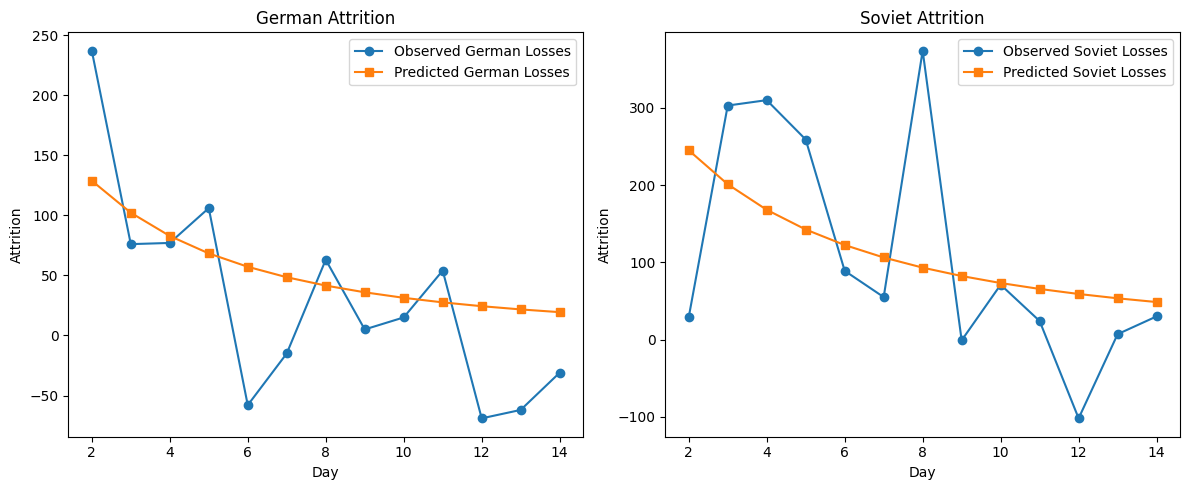

In [6]:
# Generalized Heterogeneous Lanchester Model with SSR on Attrition
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import minimize

# -------------------------------
# Step 1: Dataset (example Kursk tanks)
# -------------------------------
df = pd.DataFrame({
    # 'Day': list(range(1,15)),
    # 'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    # 'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260]


    'Day': list(range(1, 15)),
    'German_Tanks': [986,  749,    673,    596,    490,    548,    563,    500,    495,    480,    426,    495,    557,    588],
    'German_Losses': [198,  248,    121,    108,    139,    36, 63, 98, 57, 46, 79, 23, 7,  6],
    'Soviet_Tanks': [2396, 2367,   2064,   1754,   1495,   1406,   1351,   977,    978,    907,    883,    985,    978,    948],
    'Soviet_Losses': [ 105, 117,    259,    315,    289,    157,    135,    414,    117,    118,    96, 27, 42, 85]

})

# Observed daily attrition (losses per day)
obs_attrition_G = -np.diff(df['German_Tanks'].values)
obs_attrition_S = -np.diff(df['Soviet_Tanks'].values)

# -------------------------------
# Step 2: Generalized bilinear Lanchester model
# -------------------------------
def lanchester_step(G,S,a1,a2,b1,b2,p1,q1,p2,q2):
    dG = -(a1*(S**p1)*(G**q1) + a2*(S**q1)*(G**p1))
    dS = -(b1*(G**p2)*(S**q2) + b2*(G**q2)*(S**p2))
    return dG,dS

def lanchester_model(G0,S0,a1,a2,b1,b2,p1,q1,p2,q2,days,dt=1.0):
    G,S=[G0],[S0]
    pred_attrition_G, pred_attrition_S = [], []
    for t in range(1,days):
        dG,dS = lanchester_step(G[-1],S[-1],a1,a2,b1,b2,p1,q1,p2,q2)
        G.append(max(G[-1]+dt*dG,0))
        S.append(max(S[-1]+dt*dS,0))
        pred_attrition_G.append(-dG)  # predicted daily losses
        pred_attrition_S.append(-dS)
    return np.array(G),np.array(S),np.array(pred_attrition_G),np.array(pred_attrition_S)

# -------------------------------
# Step 3: SSR with respect to attrition
# -------------------------------
def SSR(params):
    a1,a2,b1,b2,p1,q1,p2,q2=params
    G_sim,S_sim,predG,predS=lanchester_model(df['German_Tanks'].iloc[0],
                                             df['Soviet_Tanks'].iloc[0],
                                             a1,a2,b1,b2,p1,q1,p2,q2,len(df))
    # Residuals between observed and predicted attrition
    resG = obs_attrition_G - predG
    resS = obs_attrition_S - predS
    return np.sum(resG**2 + resS**2)

# -------------------------------
# Step 4: Parameter estimation
# -------------------------------
init=[1e-8,1e-8,1e-8,1e-8,1.0,1.0,1.0,1.0]
bounds=[(1e-10,1e-3)]*4+[(0,2)]*4
res=minimize(SSR,init,bounds=bounds)

print("===== Estimated Parameters (SSR on Attrition) =====")
print(f"A1 = {res.x[0]:.6e}, A2 = {res.x[1]:.6e}, B1 = {res.x[2]:.6e}, B2 = {res.x[3]:.6e}")
print(f"P1 = {res.x[4]:.3f}, Q1 = {res.x[5]:.3f}, P2 = {res.x[6]:.3f}, Q2 = {res.x[7]:.3f}")
print(f"Final SSR (Attrition-based) = {res.fun:.3f}")

# -------------------------------
# Step 5: Compare observed vs predicted attrition
# -------------------------------
G_sim,S_sim,predG,predS = lanchester_model(df['German_Tanks'].iloc[0],
                                           df['Soviet_Tanks'].iloc[0],
                                           *res.x,len(df))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(df['Day'][1:],obs_attrition_G,'o-',label='Observed German Losses')
plt.plot(df['Day'][1:],predG,'s-',label='Predicted German Losses')
plt.xlabel('Day'); plt.ylabel('Attrition'); plt.title('German Attrition')
plt.legend()

plt.subplot(1,2,2)
plt.plot(df['Day'][1:],obs_attrition_S,'o-',label='Observed Soviet Losses')
plt.plot(df['Day'][1:],predS,'s-',label='Predicted Soviet Losses')
plt.xlabel('Day'); plt.ylabel('Attrition'); plt.title('Soviet Attrition')
plt.legend()
plt.tight_layout(); plt.show()


